# Uses all sequences to infer fitness but only compares against Obermeyer et al. model for the subset of sequences which appear between WT and Omicron (with no other mutations in the RBD) 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scipy.stats
from tqdm import tqdm
from cycler import cycler

In [22]:
# converts an index to a Hamming graph position
def ind2sub(ind,K,L):
    if ind == 0:
        return np.zeros(L, dtype=int)
    else:
        mysub = int(np.base_repr(ind,K))
        digits = int(math.log10(mysub))+1
        mysub_str = '0'*(L-digits) + str(mysub)
        unjoined = list(mysub_str)
        return np.array([int(i) for i in unjoined])

# converts a Hamming graph position to an index
def sub2ind(sub,K,L):
    return int(sum(np.multiply(sub,[K**(L-i-1) for i in range(L)])))

In [23]:
freq_timeseries = np.loadtxt('data/wrightfisher_freq_timeseries_L10_N1000_T1000_mu0.01_trial0.csv',delimiter=',')
wf_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('data/moran_freq_timeseries_L10_N1000_T1000_mu0.01_trial0.csv',delimiter=',')
moran_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('data/serialdilution_freq_timeseries_L10_N1000_T1000_mu0.01_trial0.csv',delimiter=',')
sd_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('covid_data/covid_freq_timeseries_T300.csv',delimiter=',')
covid_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('yeast_data/ypd_freq_timeseries_T99.csv',delimiter=',')
ypd_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('yeast_data/ypa_freq_timeseries_T110.csv',delimiter=',')
ypa_ts = freq_timeseries.T

with open('data/wrightfisher_processed_L10_N1000_T1000_mu0.01_trial0.pkl','rb') as file:
    wf_data = pickle.load(file)

with open('data/moran_processed_L10_N1000_T1000_mu0.01_trial0.pkl','rb') as file:
    moran_data = pickle.load(file)

with open('data/serialdilution_processed_L10_N1000_T1000_mu0.01_trial0.pkl','rb') as file:
    sd_data = pickle.load(file)

with open('covid_data/covid_processed_T300.pkl','rb') as file:
    covid_data = pickle.load(file)

with open('yeast_data/ypd_processed_T99.pkl','rb') as file:
    ypd_data = pickle.load(file)

with open('yeast_data/ypa_processed_T110.pkl','rb') as file:
    ypa_data = pickle.load(file)

In [24]:
# population_size = np.loadtxt('data/serialdilution_population_size_L10_N1000_T1000_mu0.01_trial0.csv',delimiter=',')
# plt.plot(population_size)
# plt.xlim(0,100)

In [25]:
# freq_timeseries[:,0:1000:4].shape

In [26]:
font = {'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 24}

plt.rc('font', **font)

In [27]:
# plt.plot(freq_timeseries[:,0:freq_timeseries.shape[1]].T)
# plt.xlim(0,freq_timeseries.shape[1])
# plt.ylim(0,1)
# plt.xlabel('Time')
# plt.ylabel('Frequency')


In [28]:
# freq_timeseries.shape

In [29]:
# with open('data/wrightfisher_processed_L10_N1000_T1000_mu0.01_trial0.pkl','rb') as file:
#     # data = pickle.load(file)

In [30]:
rare_cutoff = 10**(-3.5)
covid_rare_cutoff = 10**(-3.5)
ypd_rare_cutoff = 10**(-3)
ypa_rare_cutoff = 10**(-3)

In [31]:
# x = data['F_real'][data['timeavg_freq'] > rare_cutoff]
# y = data['F_est'][data['timeavg_freq'] > rare_cutoff]
# plt.scatter(x,y,alpha=0.8, c='#00aa66')
# # plt.xlim(3,5)
# plt.xlabel('True Fitness')
# plt.ylabel('Inferred Fitness')

# pearson = scipy.stats.pearsonr(x, y)[0]

# a, b = np.polyfit(x, y, 1)
# xrange = np.linspace(np.min(x), np.max(x), 1000)
# plt.plot(xrange, a*xrange+b, color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=0.5)

# plt.legend(loc="upper left", title=False, fontsize=16)

In [32]:
# np.exp(data['F_real'][data['timeavg_freq'] > rare_cutoff])

In [33]:
# plt.scatter(np.arange(1024),np.log(np.sort(data['timeavg_freq']))/np.log(10))

## Extract only the observed variants between WT and Omicron

In [34]:
K = 2
L = 15
wt_seq = 'NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKST'
mutated_sites = np.array([339, 371, 373, 375, 417, 440, 446, 477, 478, 484, 493, 496, 498, 501, 505],dtype=int)
mutated_indices = np.array(mutated_sites - 331*np.ones((L)),dtype=int)
wt_other_sites = np.delete(np.array(list(wt_seq)),mutated_indices)

wt_subset = [wt_seq[i] for i in mutated_indices]
omicron_subset = ['D', 'L', 'P', 'F', 'N', 'K', 'S', 'N', 'K', 'A', 'R', 'S', 'R', 'Y', 'H']

In [35]:
with open('covid_data/covid_all_seq_processed_sequences.pkl','rb') as file:
    processed_sequences = pickle.load(file)
with open('covid_data/covid_all_seq_unique_seqs.pkl','rb') as file:
    unique_seqs = pickle.load(file)
with open('covid_data/covid_all_seq_observed_indices.pkl','rb') as file:
    covid_observed_indices = pickle.load(file)

In [36]:
observed_sequences = unique_seqs[covid_observed_indices]

In [37]:
# # get indices of the relevant sequences between WT and Omicron which have no other mutations 
# relevant_seq_indices = []
# relevant_binary_seq_indices = []
# for i in tqdm(range(len(observed_sequences))):
#     seq = observed_sequences[i]
#     important_sites = np.array([seq[j] for j in mutated_indices])
#     other_sites = np.delete(np.array(list(seq)),mutated_indices)

#     binary_wt = np.array(important_sites == wt_subset,dtype=int)
#     binary_omicron = np.array(important_sites == omicron_subset,dtype=int)
#     binary_checker =  binary_wt + binary_omicron
#     if np.sum(binary_checker) != L:
#         pass
#     elif np.sum(np.array(other_sites == wt_other_sites,dtype=int)) < 186:
#         pass
#     else:
#         relevant_seq_indices.append(i)
#         relevant_binary_seq_indices.append(sub2ind(binary_omicron,K,L))
#         print(binary_omicron)

# relevant_seq_indices = np.array(relevant_seq_indices)
# relevant_binary_seq_indices = np.array(relevant_binary_seq_indices)

In [38]:
covid_F_est = covid_data['F_est'][covid_data['F_real'] == covid_data['F_real']]
covid_timeavg_freq = covid_data['timeavg_freq'][covid_data['F_real'] == covid_data['F_real']]
covid_F_real = covid_data['F_real'][covid_data['F_real'] == covid_data['F_real']]

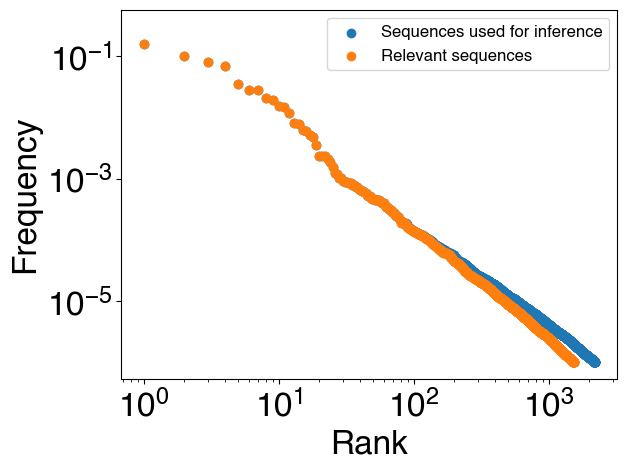

In [39]:
plt.scatter(np.arange(len(covid_data['timeavg_freq'])),np.flip(np.sort(covid_data['timeavg_freq'])))
plt.scatter(np.arange(len(covid_timeavg_freq)),np.flip(np.sort(covid_timeavg_freq)))
plt.legend(['Sequences used for inference','Relevant sequences'],fontsize=12)
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.xscale('log')
plt.yscale('log')

# Figure 1

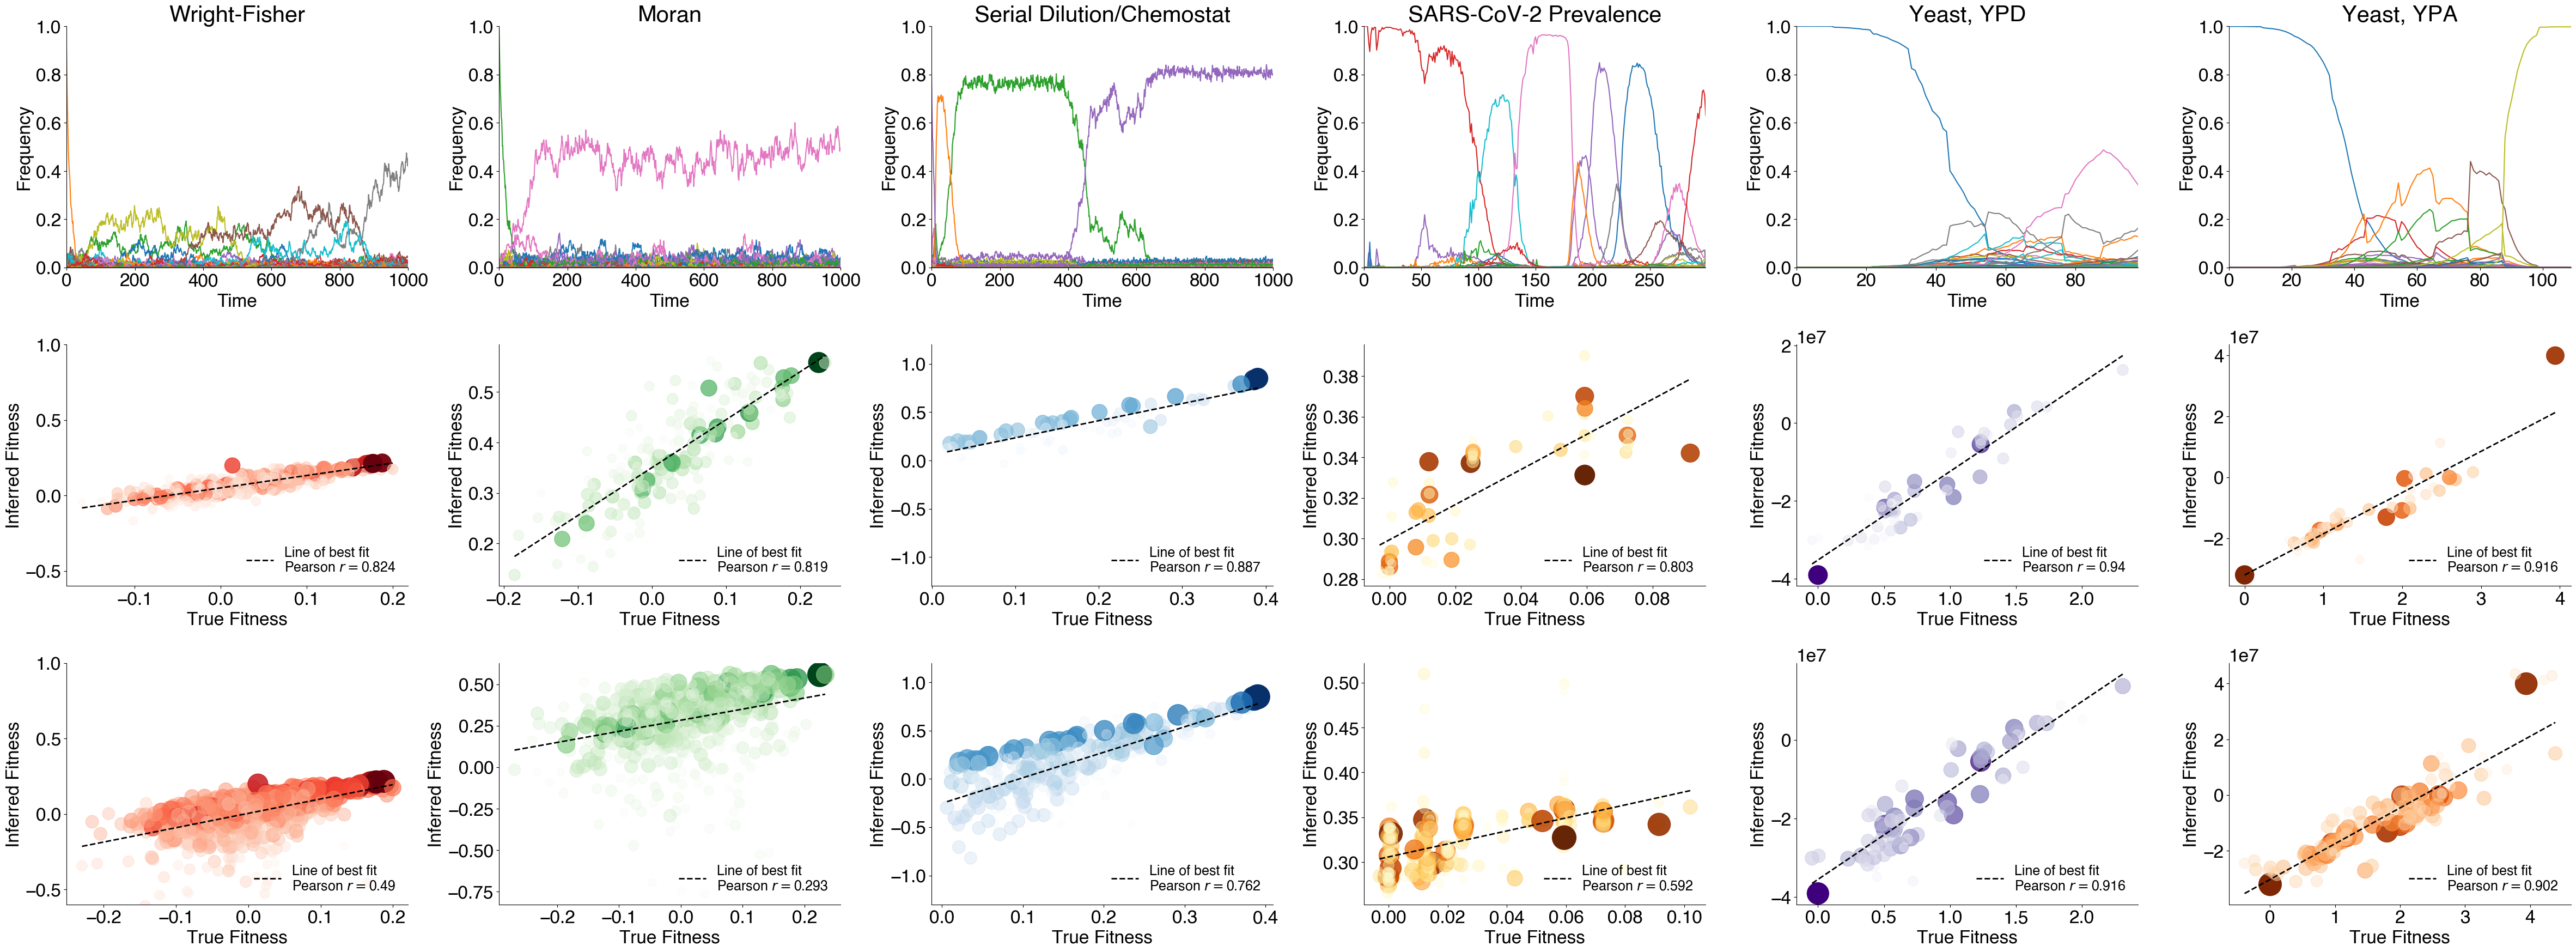

In [40]:
fig, axs = plt.subplots(3,6,figsize=(48,18))
plt.tight_layout()

# axs[0,1].set_prop_cycle(cycler('color', plt.cm.Dark2.colors))
axs[0,0].plot(wf_ts)
axs[0,0].set_xlim(0,wf_ts.shape[0])
axs[0,0].set_ylim(0,1)
axs[0,0].set_xlabel('Time')
axs[0,0].set_ylabel('Frequency')
axs[0,0].spines[['right', 'top']].set_visible(False)
axs[0,0].set_title('Wright-Fisher',fontsize=30)

# axs[0,1].set_prop_cycle(cycler('color', plt.cm.Dark2.colors))
axs[0,1].plot(moran_ts)
axs[0,1].set_xlim(0,moran_ts.shape[0])
axs[0,1].set_ylim(0,1)
axs[0,1].set_xlabel('Time')
axs[0,1].set_ylabel('Frequency')
axs[0,1].spines[['right', 'top']].set_visible(False)
axs[0,1].set_title('Moran',fontsize=30)

# axs[0,2].set_prop_cycle(cycler('color', plt.cm.Dark2.colors))
axs[0,2].plot(sd_ts)
axs[0,2].set_xlim(0,sd_ts.shape[0])
axs[0,2].set_ylim(0,1)
axs[0,2].set_xlabel('Time')
axs[0,2].set_ylabel('Frequency')
axs[0,2].spines[['right', 'top']].set_visible(False)
axs[0,2].set_title('Serial Dilution/Chemostat',fontsize=30)

# axs[0,3].set_prop_cycle(cycler('color', plt.cm.Dark2.colors))
axs[0,3].plot(covid_ts)
axs[0,3].set_xlim(0,covid_ts.shape[0]-1)
axs[0,3].set_ylim(0,1)
axs[0,3].set_xlabel('Time')
axs[0,3].set_ylabel('Frequency')
axs[0,3].spines[['right', 'top']].set_visible(False)
axs[0,3].set_title('SARS-CoV-2 Prevalence',fontsize=30)

# axs[0,3].set_prop_cycle(cycler('color', plt.cm.Dark2.colors))
axs[0,4].plot(ypd_ts)
axs[0,4].set_xlim(0,ypd_ts.shape[0]-1)
axs[0,4].set_ylim(0,1)
axs[0,4].set_xlabel('Time')
axs[0,4].set_ylabel('Frequency')
axs[0,4].spines[['right', 'top']].set_visible(False)
axs[0,4].set_title('Yeast, YPD',fontsize=30)

axs[0,5].plot(ypa_ts)
axs[0,5].set_xlim(0,ypa_ts.shape[0]-1)
axs[0,5].set_ylim(0,1)
axs[0,5].set_xlabel('Time')
axs[0,5].set_ylabel('Frequency')
axs[0,5].spines[['right', 'top']].set_visible(False)
axs[0,5].set_title('Yeast, YPA',fontsize=30)

## second row

rare_cutoff = 10**(-3.5)
covid_rare_cutoff = 10**(-3.5)
ypd_rare_cutoff = 10**(-3)
ypa_rare_cutoff = 10**(-3)

x = wf_data['F_real'][wf_data['timeavg_freq'] > rare_cutoff]
y = wf_data['F_est'][wf_data['timeavg_freq'] > rare_cutoff]
# axs[1,0].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])
axs[1,0].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Reds')
# plt.xlim(3,5)
axs[1,0].set_xlabel('True Fitness')
axs[1,0].set_ylabel('Inferred Fitness')
axs[1,0].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1,0].plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1,0].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1,0].spines[['right', 'top']].set_visible(False)

x = moran_data['F_real'][moran_data['timeavg_freq'] > rare_cutoff]
y = moran_data['F_est'][moran_data['timeavg_freq'] > rare_cutoff]
# axs[1,1].scatter(x,y,100,alpha=0.8, c='#125C53')
alphas=(2+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])
axs[1,1].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Greens')
# plt.xlim(3,5)
axs[1,1].set_xlabel('True Fitness')
axs[1,1].set_ylabel('Inferred Fitness')


pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1,1].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1,1].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1,1].spines[['right', 'top']].set_visible(False)


x = sd_data['F_real'][sd_data['timeavg_freq'] > rare_cutoff]
y = sd_data['F_est'][sd_data['timeavg_freq'] > rare_cutoff]
# axs[1,2].scatter(x,y,100,alpha=0.8, c='#144281')
alphas=(2+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])
axs[1,2].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Blues')
# plt.xlim(3,5)
axs[1,2].set_xlabel('True Fitness')
axs[1,2].set_ylabel('Inferred Fitness')
axs[1,2].set_ylim(-1.3,1.2)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1,2].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1,2].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1,2].spines[['right', 'top']].set_visible(False)

# x = covid_data['F_real'][covid_data['timeavg_freq'] > 1e-5]
# y = covid_data['F_est'][covid_data['timeavg_freq'] > 1e-5]
x = np.flip(covid_F_real[covid_timeavg_freq > covid_rare_cutoff])
y = np.flip(covid_F_est[covid_timeavg_freq > covid_rare_cutoff])
alphas = (2 + np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])-np.min(np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])))/np.max((2 + np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])-np.min(np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff]))))
marker_sizes = 200*(1+np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])-np.min(np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])))-100
colors = 100+np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])
axs[1,3].scatter(x,y,alpha=alphas, s=marker_sizes,c=colors,cmap='YlOrBr')
# '#c4ab45'
# plt.xlim(3,5)
axs[1,3].set_xlabel('True Fitness')
axs[1,3].set_ylabel('Inferred Fitness')

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1,3].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1,3].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1,3].spines[['right', 'top']].set_visible(False)
# axs[1,3].legend()

x = ypd_data['F_real'][ypd_data['timeavg_freq'] > ypd_rare_cutoff]
y = ypd_data['F_est'][ypd_data['timeavg_freq'] > ypd_rare_cutoff]
# axs[1,2].scatter(x,y,100,alpha=0.8, c='#144281')
alphas=(2+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])))/np.max((2+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff]))))
marker_sizes = 200*(1+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])))-100
colors = 100+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])
axs[1,4].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Purples')
# plt.xlim(3,5)
axs[1,4].set_xlabel('True Fitness')
axs[1,4].set_ylabel('Inferred Fitness')

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1,4].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1,4].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1,4].spines[['right', 'top']].set_visible(False)

x = ypa_data['F_real'][ypa_data['timeavg_freq'] > ypa_rare_cutoff]
y = ypa_data['F_est'][ypa_data['timeavg_freq'] > ypa_rare_cutoff]
# axs[1,2].scatter(x,y,100,alpha=0.8, c='#144281')
alphas=(2+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])))/np.max((2+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff]))))
marker_sizes = 200*(1+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])))-100
colors = 100+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])
axs[1,5].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Oranges')
# plt.xlim(3,5)
axs[1,5].set_xlabel('True Fitness')
axs[1,5].set_ylabel('Inferred Fitness')

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1,5].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1,5].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1,5].spines[['right', 'top']].set_visible(False)


## third row

rare_cutoff = 10**(-5)
covid_rare_cutoff = 10**(-5)
ypd_rare_cutoff = 0
ypa_rare_cutoff = 0

x = wf_data['F_real'][wf_data['timeavg_freq'] > rare_cutoff]
y = wf_data['F_est'][wf_data['timeavg_freq'] > rare_cutoff]
# axs[1,0].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])
axs[2,0].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Reds')
# plt.xlim(3,5)
axs[2,0].set_xlabel('True Fitness')
axs[2,0].set_ylabel('Inferred Fitness')
axs[2,0].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2,0].plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2,0].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2,0].spines[['right', 'top']].set_visible(False)

x = moran_data['F_real'][moran_data['timeavg_freq'] > rare_cutoff]
y = moran_data['F_est'][moran_data['timeavg_freq'] > rare_cutoff]
# axs[1,1].scatter(x,y,100,alpha=0.8, c='#125C53')
alphas=(2+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])
axs[2,1].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Greens')
# plt.xlim(3,5)
axs[2,1].set_xlabel('True Fitness')
axs[2,1].set_ylabel('Inferred Fitness')


pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2,1].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2,1].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2,1].spines[['right', 'top']].set_visible(False)


x = sd_data['F_real'][sd_data['timeavg_freq'] > rare_cutoff]
y = sd_data['F_est'][sd_data['timeavg_freq'] > rare_cutoff]
# axs[1,2].scatter(x,y,100,alpha=0.8, c='#144281')
alphas=(2+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])
axs[2,2].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Blues')
# plt.xlim(3,5)
axs[2,2].set_xlabel('True Fitness')
axs[2,2].set_ylabel('Inferred Fitness')
axs[2,2].set_ylim(-1.3,1.2)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2,2].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2,2].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2,2].spines[['right', 'top']].set_visible(False)

# x = covid_data['F_real'][covid_data['timeavg_freq'] > 1e-5]
# y = covid_data['F_est'][covid_data['timeavg_freq'] > 1e-5]
x = np.flip(covid_F_real[covid_timeavg_freq > covid_rare_cutoff])
y = np.flip(covid_F_est[covid_timeavg_freq > covid_rare_cutoff])
alphas = (2 + np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])-np.min(np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])))/np.max((2 + np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])-np.min(np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff]))))
marker_sizes = 200*(1+np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])-np.min(np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])))-100
colors = 100+np.log10(covid_timeavg_freq[covid_timeavg_freq > covid_rare_cutoff])
axs[2,3].scatter(x,y,alpha=alphas, s=marker_sizes,c=colors,cmap='YlOrBr')
# '#c4ab45'
# plt.xlim(3,5)
axs[2,3].set_xlabel('True Fitness')
axs[2,3].set_ylabel('Inferred Fitness')

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2,3].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2,3].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2,3].spines[['right', 'top']].set_visible(False)
# axs[1,3].legend()

x = ypd_data['F_real'][ypd_data['timeavg_freq'] > ypd_rare_cutoff]
y = ypd_data['F_est'][ypd_data['timeavg_freq'] > ypd_rare_cutoff]
# axs[1,2].scatter(x,y,100,alpha=0.8, c='#144281')
alphas=(2+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])))/np.max((2+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff]))))
marker_sizes = 200*(1+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])-np.min(np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])))-100
colors = 100+np.log10(ypd_data['timeavg_freq'][ypd_data['timeavg_freq'] > ypd_rare_cutoff])
axs[2,4].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Purples')
# plt.xlim(3,5)
axs[2,4].set_xlabel('True Fitness')
axs[2,4].set_ylabel('Inferred Fitness')

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2,4].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2,4].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2,4].spines[['right', 'top']].set_visible(False)


x = ypa_data['F_real'][ypa_data['timeavg_freq'] > ypa_rare_cutoff]
y = ypa_data['F_est'][ypa_data['timeavg_freq'] > ypa_rare_cutoff]
# axs[1,2].scatter(x,y,100,alpha=0.8, c='#144281')
alphas=(2+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])))/np.max((2+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff]))))
marker_sizes = 200*(1+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])-np.min(np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])))-100
colors = 100+np.log10(ypa_data['timeavg_freq'][ypa_data['timeavg_freq'] > ypa_rare_cutoff])
axs[2,5].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Oranges')
# plt.xlim(3,5)
axs[2,5].set_xlabel('True Fitness')
axs[2,5].set_ylabel('Inferred Fitness')

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2,5].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2,5].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2,5].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.savefig('plots/main_poster_figure.pdf')

# Intro figure

In [217]:
font = {'family' : 'Helvetica Neue',
        'weight' : 'normal',
        'size'   : 30}

plt.rc('font', **font)

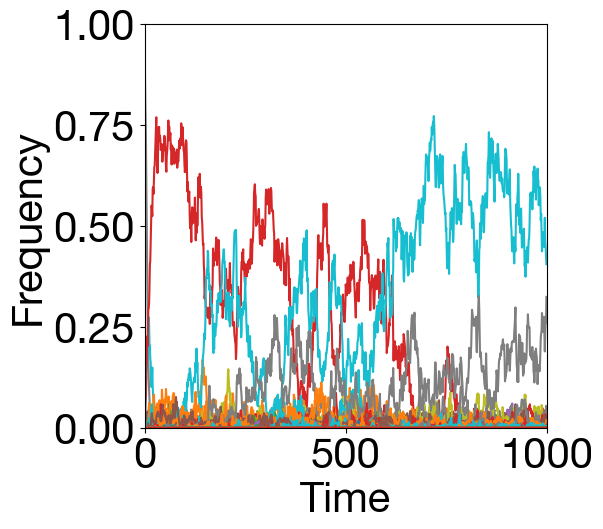

In [218]:
plt.figure(figsize=(6.5,6))
plt.plot(sd_ts)
plt.xlim(0,sd_ts.shape[0])
plt.ylim(0,1)
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/stochastic.pdf')

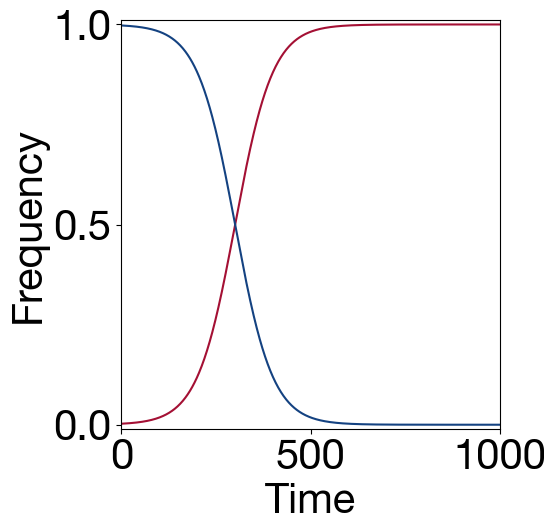

In [219]:
plt.figure(figsize=(6.5,6))
xrange = np.arange(1000)
plt.plot(xrange,np.exp(0.02*(xrange-300))/(1+ np.exp(0.02*(xrange-300))),c='#A41034')
plt.plot(xrange,1 - np.exp(0.02*(xrange-300))/(1+ np.exp(0.02*(xrange-300))),c='#144281')
plt.xlim(0,1000)
plt.ylim(-0.01,1.01)
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/logistic.pdf')

# Final column

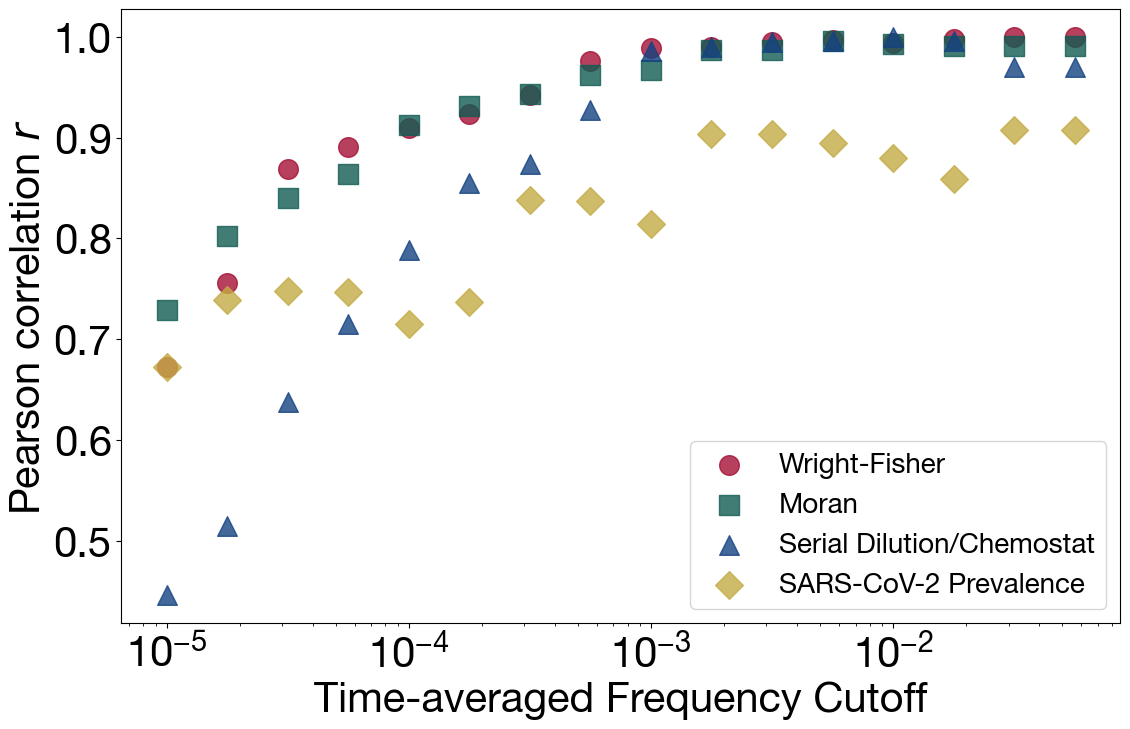

In [220]:
plt.figure(figsize=(12,8))
plt.scatter(10**wf_data['correlation_data']['rare_cutoffs_log10'][:-4],wf_data['correlation_data']['pearson_values'][:-4],200,c='#A41034',alpha=0.8,marker='o',label='Wright-Fisher')
plt.scatter(10**moran_data['correlation_data']['rare_cutoffs_log10'][:-4],moran_data['correlation_data']['pearson_values'][:-4],200,c='#125C53',alpha=0.8,marker='s',label='Moran')
plt.scatter(10**sd_data['correlation_data']['rare_cutoffs_log10'][:-4],sd_data['correlation_data']['pearson_values'][:-4],200,c='#144281',alpha=0.8,marker='^',label='Serial Dilution/Chemostat')
plt.scatter(10**covid_data['correlation_data']['rare_cutoffs_log10'][:-4],covid_data['correlation_data']['pearson_values'][:-4],200,c='#c4ab45',alpha=0.8,marker='D',label='SARS-CoV-2 Prevalence')

plt.xlabel('Time-averaged Frequency Cutoff')
plt.ylabel('Pearson correlation $r$')
plt.xscale('log')
plt.legend(fontsize=20)
plt.tight_layout()

plt.savefig('plots/correlations_vs_freq.pdf')

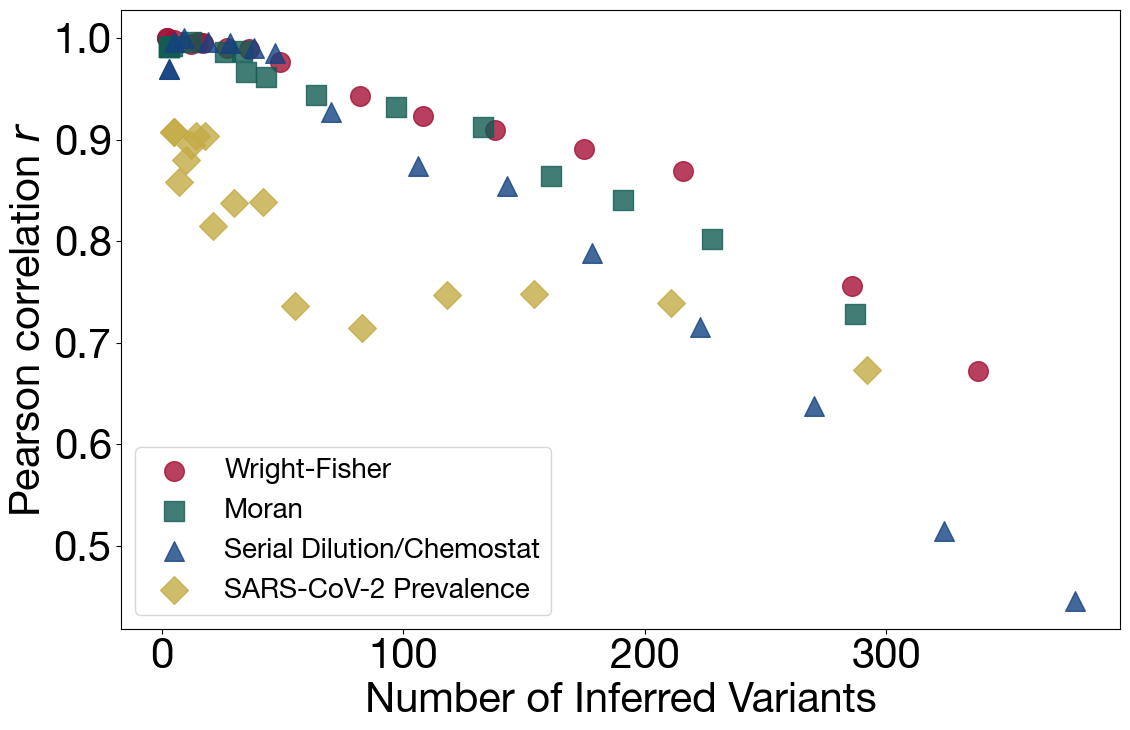

In [221]:
plt.figure(figsize=(12,8))
plt.scatter(wf_data['correlation_data']['N_common_variants'][:-4],wf_data['correlation_data']['pearson_values'][:-4],200,c='#A41034',alpha=0.8,marker='o',label='Wright-Fisher')
plt.scatter(moran_data['correlation_data']['N_common_variants'][:-4],moran_data['correlation_data']['pearson_values'][:-4],200,c='#125C53',alpha=0.8,marker='s',label='Moran')
plt.scatter(sd_data['correlation_data']['N_common_variants'][:-4],sd_data['correlation_data']['pearson_values'][:-4],200,c='#144281',alpha=0.8,marker='^',label='Serial Dilution/Chemostat')
plt.scatter(covid_data['correlation_data']['N_common_variants'][:-4],covid_data['correlation_data']['pearson_values'][:-4],200,c='#c4ab45',alpha=0.8,marker='D',label='SARS-CoV-2 Prevalence')

plt.xlabel('Number of Inferred Variants')
plt.ylabel('Pearson correlation $r$')
# plt.xscale('log')
plt.legend(fontsize=20,loc='lower left')
plt.tight_layout()

plt.savefig('plots/correlations_vs_freq.pdf')

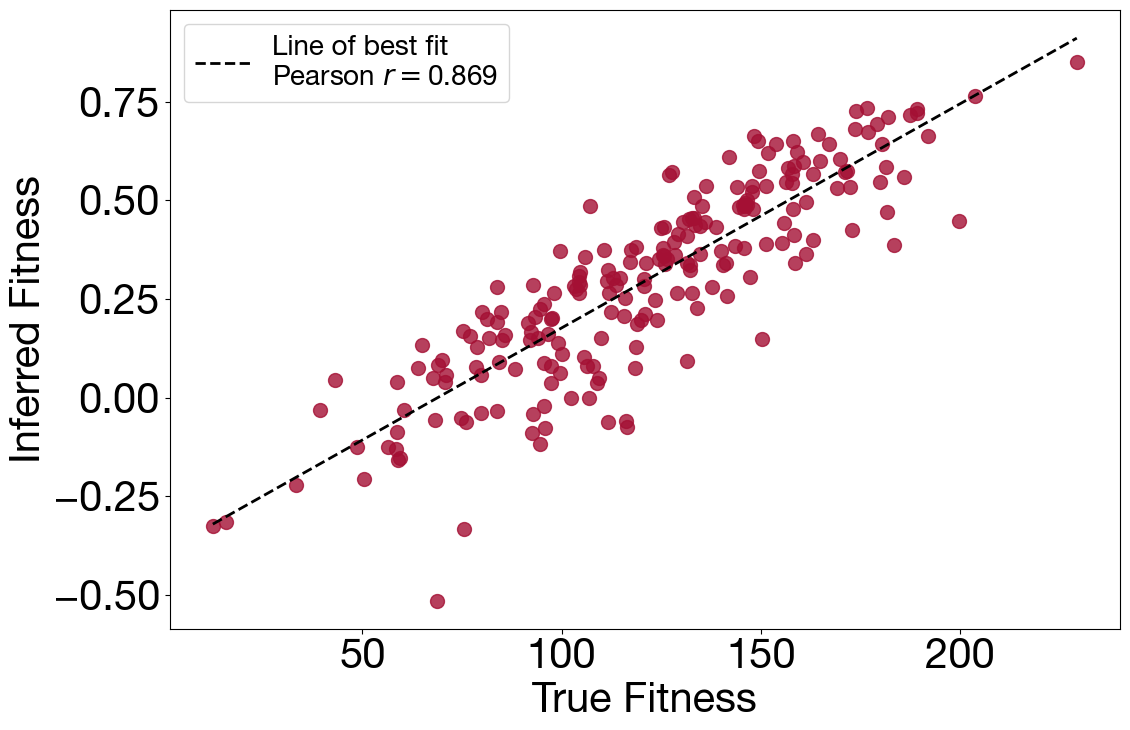

In [222]:
rare_cutoff = 10**(-4.5)

plt.figure(figsize=(12,8))
x = wf_data['F_real'][wf_data['timeavg_freq'] > rare_cutoff]
y = wf_data['F_est'][wf_data['timeavg_freq'] > rare_cutoff]
plt.scatter(x,y,100,alpha=0.8, c='#A41034')
# plt.xlim(3,5)
plt.xlabel('True Fitness')
plt.ylabel('Inferred Fitness')

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
plt.plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
plt.legend(loc="upper left", title=False, fontsize=20)

plt.tight_layout()

plt.savefig('plots/morepoints_wf.pdf')